# 📊 Customer Retention & Churn Analysis
**Future Interns — Data Science & Analytics | Task 2**

---

## 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2️⃣ Load Dataset

In [2]:
df = pd.read_csv('../dataset/telecom_churn_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1500, 18)


,CustomerID,Gender,Age,SeniorCitizen,Dependents,Region,Tenure_Months,Contract,InternetService,TechSupport,PaymentMethod,NumProducts,MonthlyCharges,TotalCharges,JoinDate,Churn,ChurnReason,CohortMonth
0,CUST0001,Male,53,0,No,West,52,Two Year,DSL,No,Bank Transfer,2,83.77,4354.28,2023-10-17,0,NaN,2023-10
1,CUST0002,Male,21,0,Yes,North,15,Month-to-Month,Fiber Optic,No,Mailed Check,2,85.87,1308.34,2022-04-25,1,Financial Constraints,2022-04
2,CUST0003,Male,26,1,Yes,South,72,Two Year,Fiber Optic,No,Credit Card,3,35.66,2524.32,2022-01-26,0,NaN,2022-01
3,CUST0004,Male,25,0,Yes,North,61,Month-to-Month,No Internet,Yes,Credit Card,1,52.51,3172.49,2022-10-09,1,Poor Customer Service,2022-10
4,CUST0005,Female,19,0,No,West,21,Month-to-Month,DSL,Yes,Electronic Check,2,77.36,1596.02,2022-09-08,1,Moved Away,2022-09


In [3]:
print('📋 Dataset Info:')
df.info()
print('\n📊 Missing Values:')
print(df.isnull().sum())

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1500 non-null   object 
 1   Gender           1500 non-null   object 
 2   Age              1500 non-null   int64  
 3   SeniorCitizen    1500 non-null   int64  
 4   Dependents       1500 non-null   object 
 5   Region           1500 non-null   object 
 6   Tenure_Months    1500 non-null   int64  
 7   Contract         1500 non-null   object 
 8   InternetService  1500 non-null   object 
 9   TechSupport      1500 non-null   object 
 10  PaymentMethod    1500 non-null   object 
 11  NumProducts      1500 non-null   int64  
 12  MonthlyCharges   1500 non-null   float64
 13  TotalCharges     1500 non-null   float64
 14  JoinDate         1500 non-null   object 
 15  Churn            1500 non-null   int64  
 16  ChurnReason      477 non-null    object 
 17

In [4]:
print('📈 Basic Statistics:')
df.describe().round(2)

📈 Basic Statistics:


,Age,SeniorCitizen,Tenure_Months,NumProducts,MonthlyCharges,TotalCharges,Churn
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,44.02,0.15,35.87,2.15,64.53,2323.63,0.32
std,14.99,0.36,20.86,0.97,26.03,1749.25,0.47
min,18.00,0.00,1.00,1.00,20.02,-11.12,0.00
25%,31.00,0.00,17.00,1.00,41.85,960.51,0.00
50%,45.00,0.00,36.00,2.00,63.89,1893.51,0.00
75%,57.00,0.00,54.00,3.00,88.07,3426.73,1.00
max,69.00,1.00,72.00,4.00,109.95,7679.81,1.00


## 3️⃣ Data Cleaning

In [5]:
df['JoinDate'] = pd.to_datetime(df['JoinDate'])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

df['Churn_Label'] = df['Churn'].map({1: 'Churned', 0: 'Retained'})
df['Tenure_Group'] = pd.cut(df['Tenure_Months'],
    bins=[0,6,12,24,36,72],
    labels=['0-6 months','7-12 months','13-24 months','25-36 months','36+ months'])
df['Charge_Group'] = pd.cut(df['MonthlyCharges'],
    bins=[0,30,50,70,90,120],
    labels=['₹0-30','₹31-50','₹51-70','₹71-90','₹90+'])

print(f'✅ Cleaned dataset: {df.shape[0]} rows')
print(f'✅ Overall Churn Rate: {df["Churn"].mean()*100:.1f}%')

✅ Cleaned dataset: 1500 rows
✅ Overall Churn Rate: 31.8%


## 4️⃣ KPI Summary

In [6]:
total = len(df)
churned = df['Churn'].sum()
retained = total - churned
churn_rate = churned/total*100
avg_tenure = df['Tenure_Months'].mean()
avg_monthly = df['MonthlyCharges'].mean()
revenue_lost = df[df['Churn']==1]['TotalCharges'].sum()

print('='*45)
print(f'  Total Customers     : {total:,}')
print(f'  Retained Customers  : {retained:,}')
print(f'  Churned Customers   : {churned:,}')
print(f'  Churn Rate          : {churn_rate:.1f}%')
print(f'  Avg Tenure          : {avg_tenure:.1f} months')
print(f'  Avg Monthly Charge  : ₹{avg_monthly:.2f}')
print(f'  Revenue at Risk     : ₹{revenue_lost:,.0f}')
print('='*45)

  Total Customers     : 1,500
  Retained Customers  : 1,023
  Churned Customers   : 477
  Churn Rate          : 31.8%
  Avg Tenure          : 35.9 months
  Avg Monthly Charge  : ₹64.53
  Revenue at Risk     : ₹1,053,679


## 5️⃣ Univariate Analysis

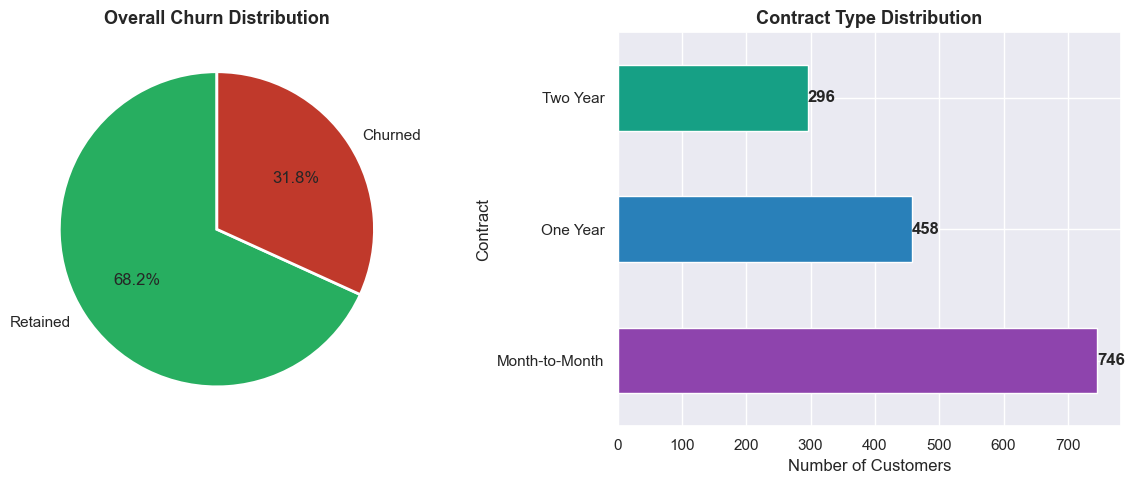

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

colors = ['#27ae60','#c0392b']
df['Churn_Label'].value_counts().plot(kind='pie', ax=axes[0], colors=colors,
    autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Overall Churn Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('')

df['Contract'].value_counts().plot(kind='barh', ax=axes[1],
    color=['#8e44ad','#2980b9','#16a085'], edgecolor='white')
axes[1].set_title('Contract Type Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Customers')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y()+p.get_height()/2.), ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

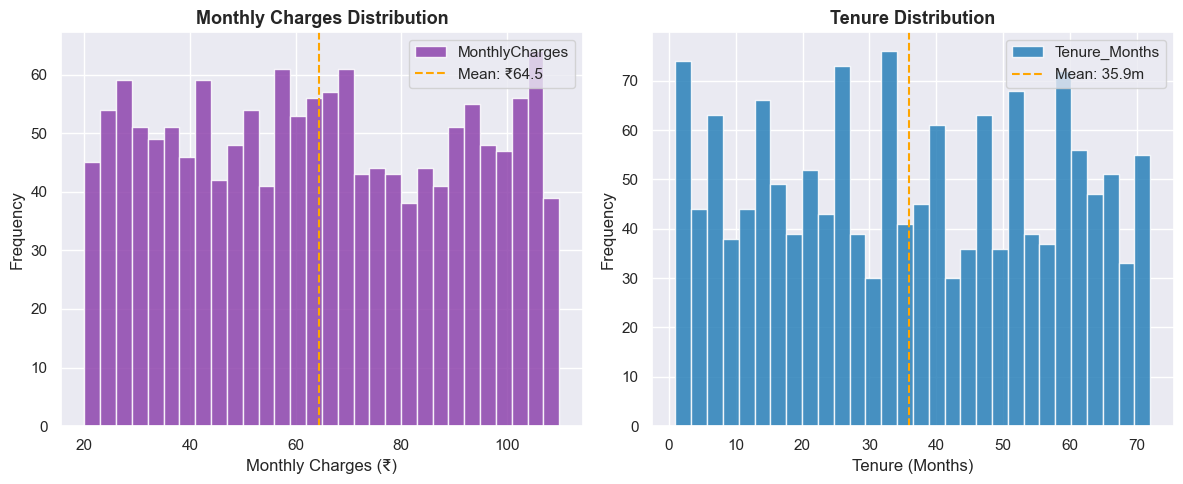

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

df['MonthlyCharges'].plot(kind='hist', bins=30, ax=axes[0], color='#8e44ad', edgecolor='white', alpha=0.85)
axes[0].set_title('Monthly Charges Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monthly Charges (₹)')
axes[0].axvline(df['MonthlyCharges'].mean(), color='orange', linestyle='--', label=f'Mean: ₹{df["MonthlyCharges"].mean():.1f}')
axes[0].legend()

df['Tenure_Months'].plot(kind='hist', bins=30, ax=axes[1], color='#2980b9', edgecolor='white', alpha=0.85)
axes[1].set_title('Tenure Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].axvline(df['Tenure_Months'].mean(), color='orange', linestyle='--', label=f'Mean: {df["Tenure_Months"].mean():.1f}m')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/02_charges_tenure_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 6️⃣ Bivariate Analysis

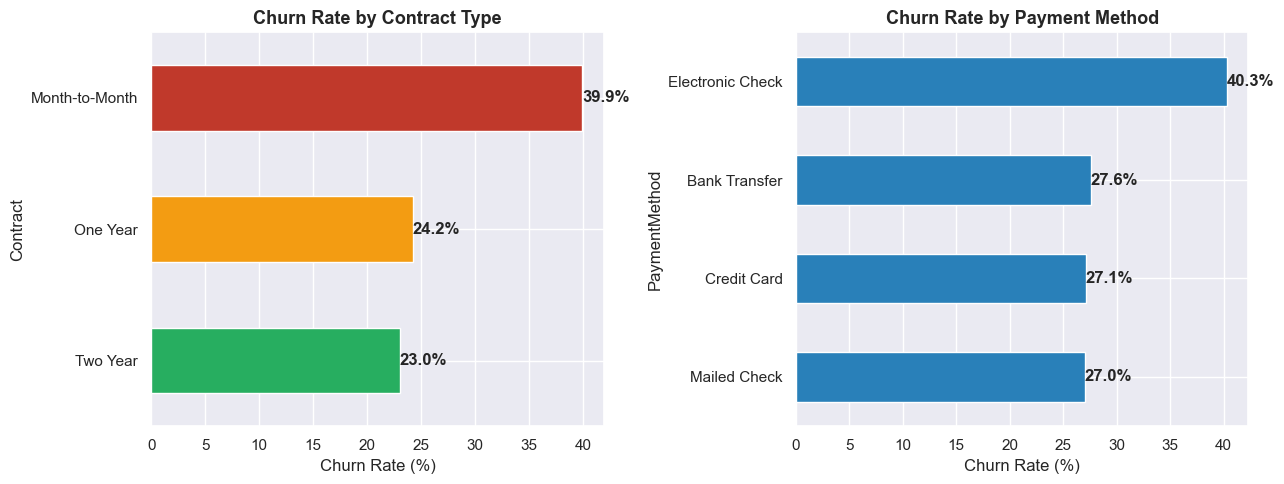

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

ct = df.groupby('Contract')['Churn'].mean().mul(100).round(1).sort_values(ascending=True)
ct.plot(kind='barh', ax=axes[0], color=['#27ae60','#f39c12','#c0392b'], edgecolor='white')
axes[0].set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn Rate (%)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_width():.1f}%', (p.get_width(), p.get_y()+p.get_height()/2.), ha='left', va='center', fontweight='bold')

pm = df.groupby('PaymentMethod')['Churn'].mean().mul(100).round(1).sort_values(ascending=True)
pm.plot(kind='barh', ax=axes[1], color='#2980b9', edgecolor='white')
axes[1].set_title('Churn Rate by Payment Method', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_width():.1f}%', (p.get_width(), p.get_y()+p.get_height()/2.), ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/03_churn_contract_payment.png', dpi=150, bbox_inches='tight')
plt.show()

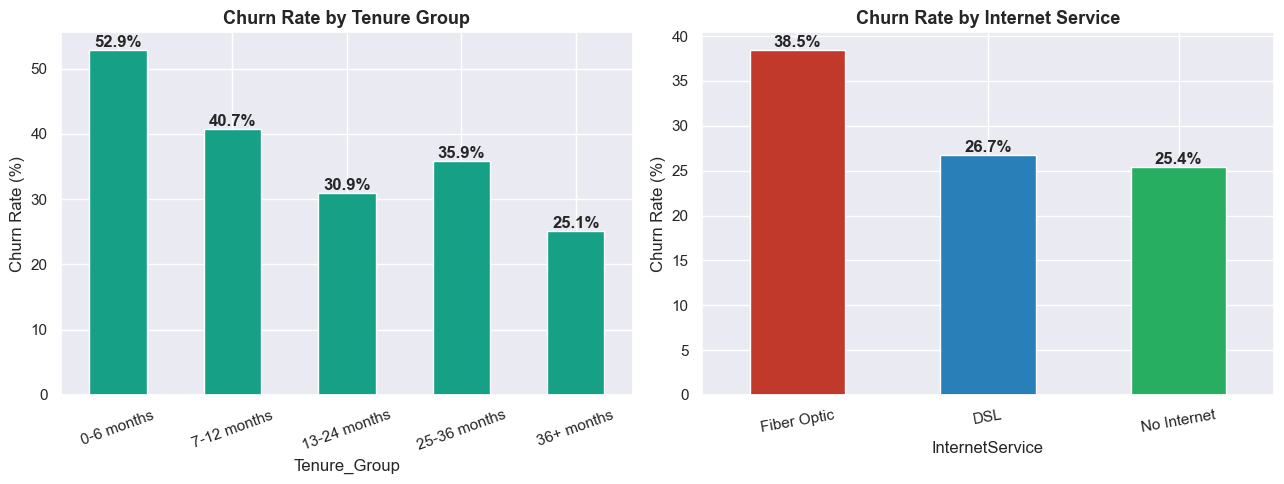

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

tg = df.groupby('Tenure_Group', observed=True)['Churn'].mean().mul(100).round(1)
tg.plot(kind='bar', ax=axes[0], color='#16a085', edgecolor='white', rot=20)
axes[0].set_title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2., p.get_height()), ha='center', va='bottom', fontweight='bold')

is_ = df.groupby('InternetService')['Churn'].mean().mul(100).round(1).sort_values(ascending=False)
is_.plot(kind='bar', ax=axes[1], color=['#c0392b','#2980b9','#27ae60'], edgecolor='white', rot=10)
axes[1].set_title('Churn Rate by Internet Service', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2., p.get_height()), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/04_churn_tenure_internet.png', dpi=150, bbox_inches='tight')
plt.show()

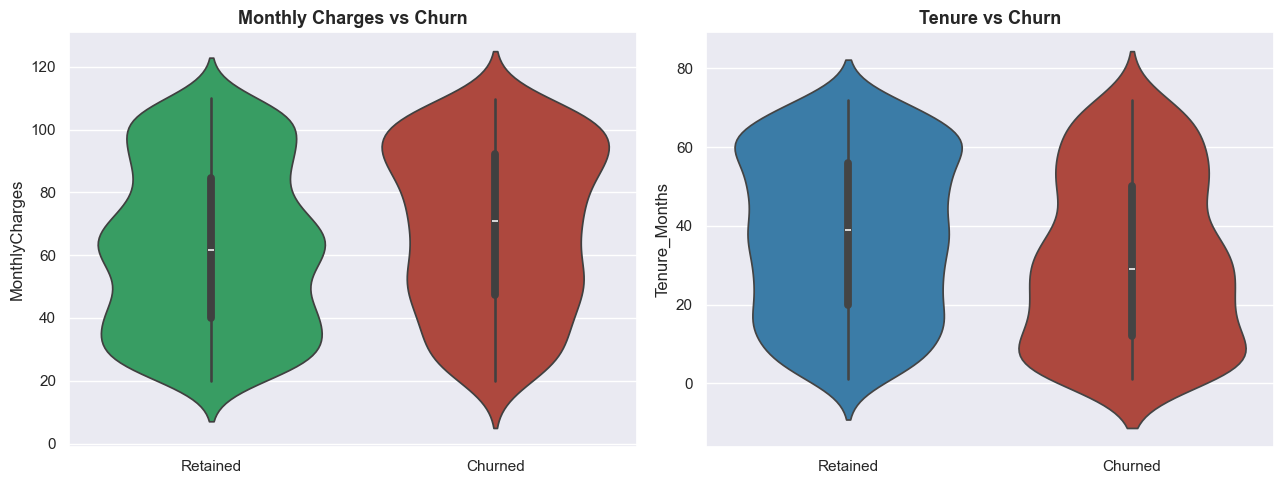

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.violinplot(data=df, x='Churn_Label', y='MonthlyCharges',
    palette={'Retained':'#27ae60','Churned':'#c0392b'}, ax=axes[0], inner='box')
axes[0].set_title('Monthly Charges vs Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')

sns.violinplot(data=df, x='Churn_Label', y='Tenure_Months',
    palette={'Retained':'#2980b9','Churned':'#c0392b'}, ax=axes[1], inner='box')
axes[1].set_title('Tenure vs Churn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('../images/05_violin_charges_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

## 7️⃣ Churn Reasons

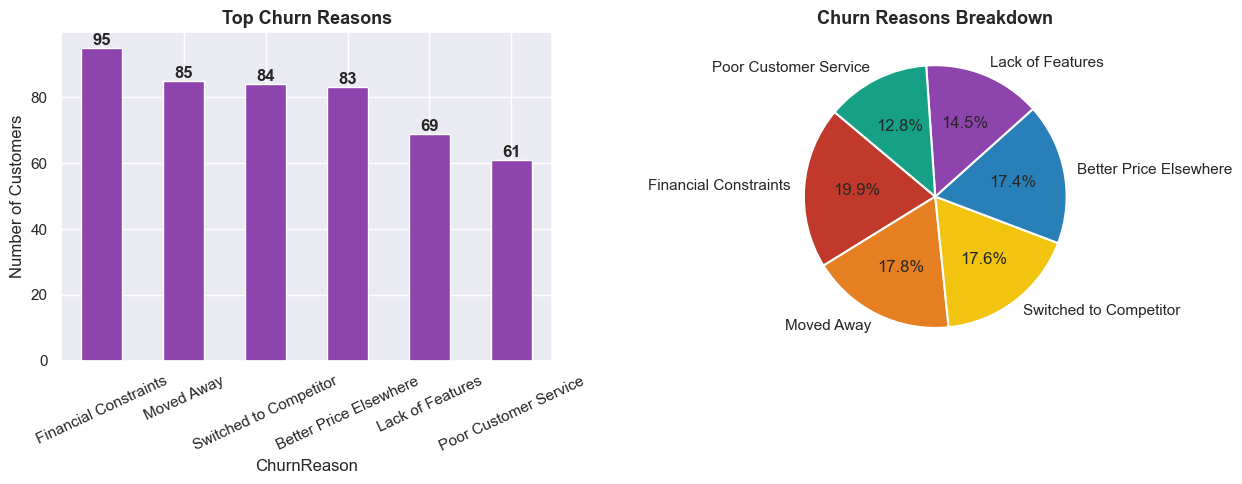

In [12]:
reasons = df[df['Churn']==1]['ChurnReason'].value_counts()

fig, axes = plt.subplots(1,2, figsize=(13,5))
reasons.plot(kind='bar', ax=axes[0], color='#8e44ad', edgecolor='white', rot=25)
axes[0].set_title('Top Churn Reasons', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2., p.get_height()), ha='center', va='bottom', fontweight='bold')

wedge_colors=['#c0392b','#e67e22','#f1c40f','#2980b9','#8e44ad','#16a085']
axes[1].pie(reasons, labels=reasons.index, autopct='%1.1f%%', startangle=140,
    colors=wedge_colors, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Churn Reasons Breakdown', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/06_churn_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

## 8️⃣ Cohort Retention Analysis

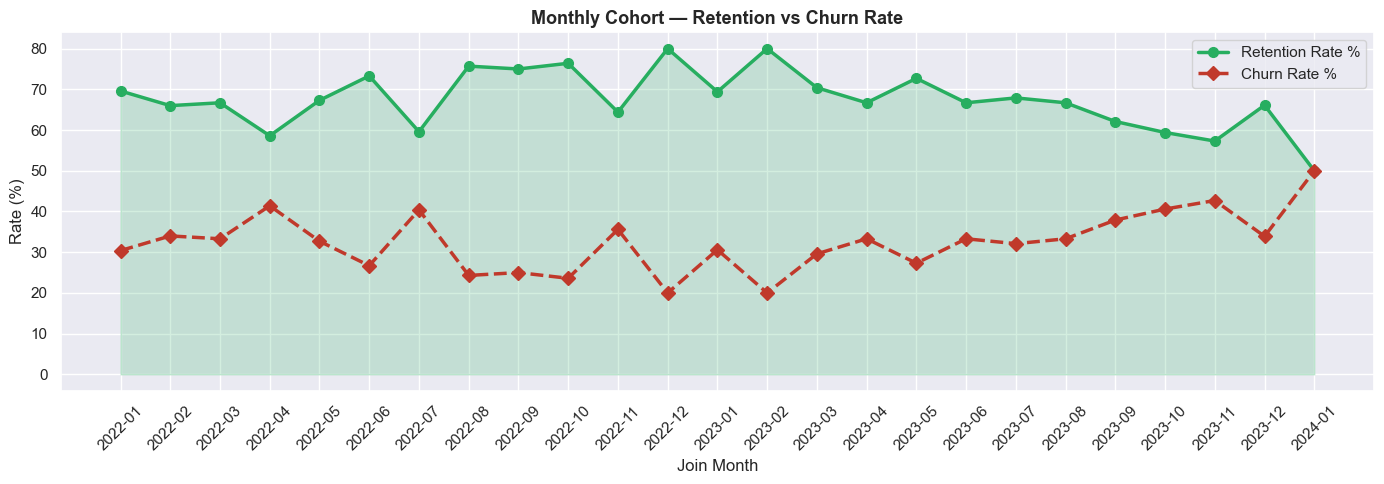

In [13]:
cohort = df.groupby('CohortMonth').agg(Total=('Churn','count'),Churned=('Churn','sum')).reset_index()
cohort['RetentionRate'] = ((cohort['Total']-cohort['Churned'])/cohort['Total']*100).round(1)
cohort['ChurnRate'] = (cohort['Churned']/cohort['Total']*100).round(1)
cohort = cohort.sort_values('CohortMonth')

fig, ax = plt.subplots(figsize=(14,5))
ax.fill_between(cohort['CohortMonth'], cohort['RetentionRate'], alpha=0.2, color='#27ae60')
ax.plot(cohort['CohortMonth'], cohort['RetentionRate'], marker='o', color='#27ae60', linewidth=2.5, markersize=7, label='Retention Rate %')
ax.plot(cohort['CohortMonth'], cohort['ChurnRate'], marker='D', color='#c0392b', linewidth=2.5, markersize=7, label='Churn Rate %', linestyle='--')
ax.set_title('Monthly Cohort — Retention vs Churn Rate', fontsize=13, fontweight='bold')
ax.set_xlabel('Join Month'); ax.set_ylabel('Rate (%)')
ax.legend(); plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/07_cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()

## 9️⃣ Correlation Heatmap

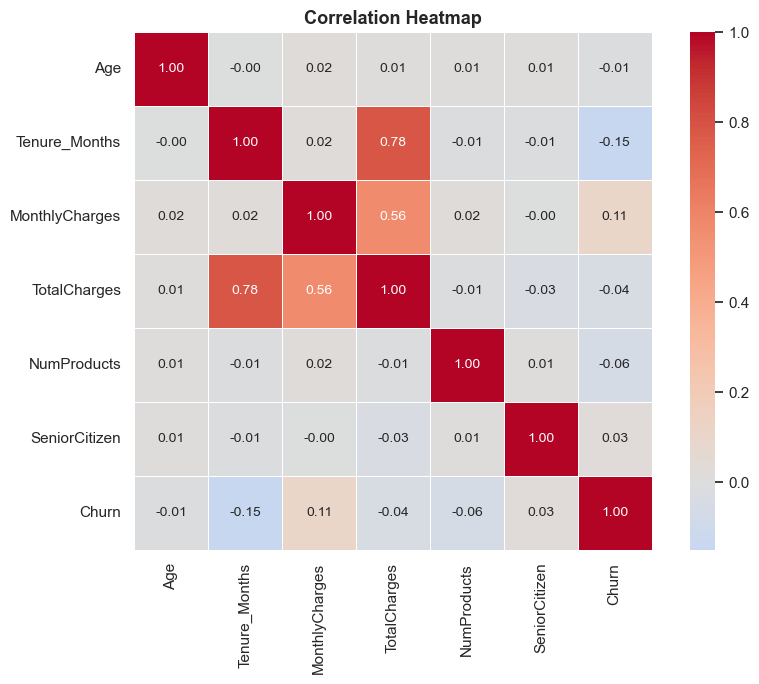

In [14]:
num_cols = ['Age','Tenure_Months','MonthlyCharges','TotalCharges','NumProducts','SeniorCitizen','Churn']
corr = df[num_cols].corr().round(2)
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5, square=True, annot_kws={'size':10})
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔟 Key Insights

In [15]:
print('='*55)
print('       📌 KEY INSIGHTS — CHURN ANALYSIS')
print('='*55)
print(f'1. Overall Churn Rate          : {df["Churn"].mean()*100:.1f}%')
print(f'2. Month-to-Month Churn Rate   : {df[df["Contract"]=="Month-to-Month"]["Churn"].mean()*100:.1f}%')
print(f'3. Two Year Contract Churn     : {df[df["Contract"]=="Two Year"]["Churn"].mean()*100:.1f}%')
print(f'4. Fiber Optic Churn Rate      : {df[df["InternetService"]=="Fiber Optic"]["Churn"].mean()*100:.1f}%')
print(f'5. Electronic Check Churn      : {df[df["PaymentMethod"]=="Electronic Check"]["Churn"].mean()*100:.1f}%')
print(f'6. Early Churn (0-6 months)    : {df[df["Tenure_Months"]<=6]["Churn"].mean()*100:.1f}%')
print(f'7. Long-term Churn (>36m)      : {df[df["Tenure_Months"]>36]["Churn"].mean()*100:.1f}%')
print(f'8. Revenue at Risk             : ₹{df[df["Churn"]==1]["TotalCharges"].sum():,.0f}')
print('='*55)

       📌 KEY INSIGHTS — CHURN ANALYSIS
1. Overall Churn Rate          : 31.8%
2. Month-to-Month Churn Rate   : 39.9%
3. Two Year Contract Churn     : 23.0%
4. Fiber Optic Churn Rate      : 38.5%
5. Electronic Check Churn      : 40.3%
6. Early Churn (0-6 months)    : 52.9%
7. Long-term Churn (>36m)      : 25.1%
8. Revenue at Risk             : ₹1,053,679
